Planilhas carregadas: (5900, 9) (14, 5) (12, 3)

Total de oportunidades com jornada mapeada: 1610
Estados transientes: ['Solicitação de material', 'Material entregue', 'Validação pedagógica', 'Proposta tabela', 'Proposta personalizada', 'Negociação e ajuste financeiro', 'Documentação enviada', 'Análise de operações comerciais', 'Análise do Financeiro', 'Análise do Jurídico', 'Enviado para a assinatura']
Estados absorventes: ['Contrato assinado', 'Oportunidade perdida']

Finalizadas (ganhas ou perdidas): 910
  -> Ganhas (Contrato assinado): 40
  -> Perdidas: 870
Em aberto (ainda em andamento): 700

=== Matriz de transição (probabilidades) ===
para                             Solicitação de material  Material entregue  Validação pedagógica  Proposta tabela  Proposta personalizada  Negociação e ajuste financeiro  Documentação enviada  Análise de operações comerciais  Análise do Financeiro  Análise do Jurídico  Enviado para a assinatura  Contrato assinado  Oportunidade perdida
de          

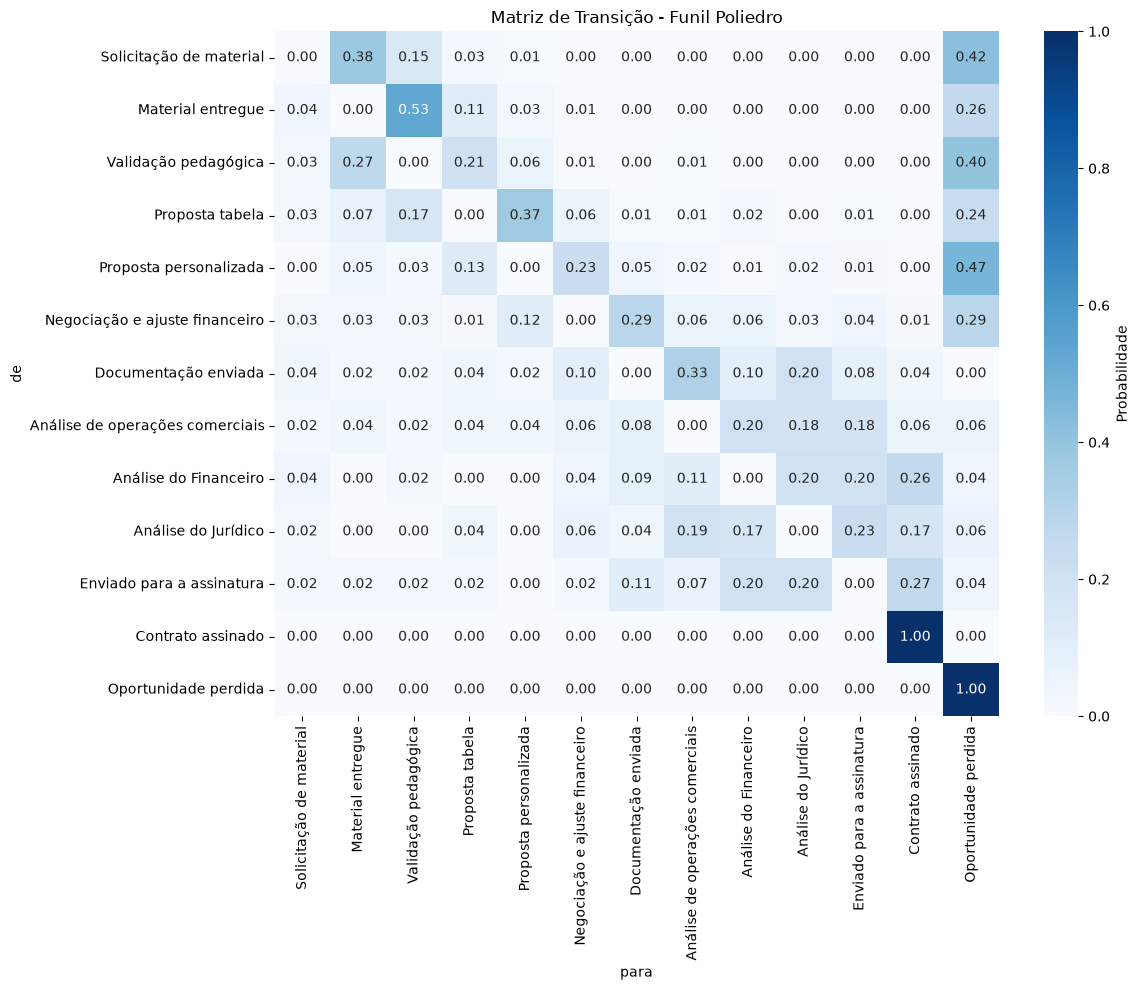


Arquivos exportados com sucesso.


In [2]:
"""
Análise de Cadeia de Markov - Funil Poliedro

"""

import pandas as pd
import numpy as np

arquivo_excel = '../dados/Proposta-de-Projeto-Base-Funil.xlsx'


def mostrar(titulo, obj):
    print(f'\n=== {titulo} ===')
    print(obj.to_string() if hasattr(obj, 'to_string') else obj)


# ==============================================================
# 1. Carregar e tratar df_funil
# ==============================================================
df_funil = pd.read_excel(arquivo_excel, sheet_name='base-funil-2026')
df_funil.columns = [
    'id_linha_evento', 'id_oportunidade', 'data_oportunidade_aberta',
    'oportunidade_atualizada', 'id_escola', 'marca_escolhida',
    'data_alteração', 'acao_da_alteração', 'valor_fincanceiro'
]
df_funil['data_oportunidade_aberta'] = pd.to_datetime(df_funil['data_oportunidade_aberta'])
df_funil['data_alteração'] = pd.to_datetime(df_funil['data_alteração'])
df_funil['valor_fincanceiro'] = pd.to_numeric(df_funil['valor_fincanceiro'], errors='coerce')

# ==============================================================
# 2. Carregar e tratar df_sequencia
# ==============================================================
df_sequencia = pd.read_excel(arquivo_excel, sheet_name='sequência-etapas-funil')
df_sequencia.columns = ['id_fase_ordem', 'fase', 'detalhe_funil', 'sequencia_funil', 'observacao']
if 'observacao' in df_sequencia.columns and df_sequencia['observacao'].isnull().all():
    df_sequencia = df_sequencia.drop(columns=['observacao'])

# ==============================================================
# 3. Carregar e tratar df_historico
# ==============================================================
df_historico = pd.read_excel(arquivo_excel, sheet_name='base-histórico-etapas')
df_historico.columns = ['fase', 'tempo_medio_poliedro_2025', 'tempo_medio_poliedro_2024']
df_historico['tempo_medio_poliedro_2025'] = pd.to_numeric(df_historico['tempo_medio_poliedro_2025'], errors='coerce')
df_historico['tempo_medio_poliedro_2024'] = pd.to_numeric(df_historico['tempo_medio_poliedro_2024'], errors='coerce')
df_historico_melted = df_historico.melt(id_vars=['fase'], var_name='ano_referencia', value_name='tempo_medio_dias')
df_historico_melted['ano'] = df_historico_melted['ano_referencia'].str.extract(r'(\d{4})').astype(int)
df_historico_melted = df_historico_melted.drop(columns=['ano_referencia'])

print('Planilhas carregadas:', df_funil.shape, df_sequencia.shape, df_historico_melted.shape)


# ==============================================================
# 8. Sequências de estados por oportunidade
# ==============================================================
df_funil_ordenado = df_funil.sort_values(['id_oportunidade', 'data_alteração'])
sequencias = df_funil_ordenado.groupby('id_oportunidade')['oportunidade_atualizada'].apply(list)
print(f'\nTotal de oportunidades com jornada mapeada: {len(sequencias)}')


# ==============================================================
# 9. Definição dos estados (transientes + absorventes)
# ==============================================================
ESTADO_GANHO = 'Contrato assinado'
ESTADO_PERDA = 'Oportunidade perdida'
ESTADO_IGNORADO = 'Contrato Ativo'  # quase inexistente no log, não usamos como estado

estados_absorventes = [ESTADO_GANHO, ESTADO_PERDA]
estados_transientes = [
    e for e in df_sequencia['detalhe_funil'].tolist()
    if e not in estados_absorventes + [ESTADO_IGNORADO]
]
todos_estados = estados_transientes + estados_absorventes

print('Estados transientes:', estados_transientes)
print('Estados absorventes:', estados_absorventes)


# ==============================================================
# 10. Classificar oportunidades: finalizadas vs em aberto
# ==============================================================
ultimo_estado = sequencias.apply(lambda seq: seq[-1])
oportunidades_finalizadas = ultimo_estado[ultimo_estado.isin(estados_absorventes)].index
oportunidades_em_aberto = ultimo_estado[~ultimo_estado.isin(estados_absorventes)].index

print(f'\nFinalizadas (ganhas ou perdidas): {len(oportunidades_finalizadas)}')
print(f'  -> Ganhas ({ESTADO_GANHO}): {(ultimo_estado[oportunidades_finalizadas] == ESTADO_GANHO).sum()}')
print(f'  -> Perdidas: {(ultimo_estado[oportunidades_finalizadas] == ESTADO_PERDA).sum()}')
print(f'Em aberto (ainda em andamento): {len(oportunidades_em_aberto)}')


# ==============================================================
# 11. Construir a matriz de transição (só com oportunidades finalizadas)
# ==============================================================
pares_transicao = []
for opp_id in oportunidades_finalizadas:
    seq = [s for s in sequencias[opp_id] if s != ESTADO_IGNORADO]
    for i in range(len(seq) - 1):
        pares_transicao.append((seq[i], seq[i + 1]))

df_pares = pd.DataFrame(pares_transicao, columns=['de', 'para'])
matriz_contagem = pd.crosstab(df_pares['de'], df_pares['para'])
matriz_contagem = matriz_contagem.reindex(index=todos_estados, columns=todos_estados, fill_value=0)
matriz_transicao = matriz_contagem.div(matriz_contagem.sum(axis=1), axis=0).fillna(0)

# Trava os estados absorventes: 100% de chance de permanecer neles mesmos
for estado in estados_absorventes:
    matriz_transicao.loc[estado, :] = 0.0
    matriz_transicao.loc[estado, estado] = 1.0

pd.set_option('display.width', 220)
mostrar('Matriz de transição (probabilidades)', matriz_transicao.round(3))

# Checagem rápida -- toda linha tem que somar 1.0
print('\nChecagem -- soma de cada linha (todas devem dar 1.0):')
print(matriz_transicao.sum(axis=1).to_string())


# ==============================================================
# 12. Matriz fundamental e probabilidade de absorção
# ==============================================================
Q = matriz_transicao.loc[estados_transientes, estados_transientes].values
R = matriz_transicao.loc[estados_transientes, estados_absorventes].values

N = np.linalg.inv(np.eye(len(estados_transientes)) - Q)  # matriz fundamental
B = N @ R                                                  # probabilidades de absorção

df_absorcao = pd.DataFrame(
    (B * 100).round(1),
    index=estados_transientes,
    columns=[f'{c} (%)' for c in estados_absorventes]
)
mostrar('Probabilidade de absorção final, por etapa atual', df_absorcao)


# ==============================================================
# 13. Número esperado de transições até o fim
# ==============================================================
df_passos = pd.Series(N.sum(axis=1), index=estados_transientes, name='passos_esperados').round(2)
mostrar('Nº esperado de transições até ganhar ou perder', df_passos)


# ==============================================================
# 14. Cruzar com tempo médio por fase
# ==============================================================
mapa_etapa_fase = df_sequencia.set_index('detalhe_funil')['fase'].to_dict()
tempo_medio_fase = (
    df_historico_melted[df_historico_melted['ano'] == 2025]
    .set_index('fase')['tempo_medio_dias'].to_dict()
)

df_passos_fase = df_passos.reset_index()
df_passos_fase.columns = ['etapa', 'passos_esperados']
df_passos_fase['fase'] = df_passos_fase['etapa'].map(mapa_etapa_fase)
df_passos_fase['tempo_medio_fase_dias'] = df_passos_fase['fase'].map(tempo_medio_fase)
mostrar('Passos esperados cruzados com tempo médio por fase', df_passos_fase)


# ==============================================================
# 15. Prever destino das oportunidades ainda em aberto
# ==============================================================
previsoes = []
for opp_id in oportunidades_em_aberto:
    etapa_atual = sequencias[opp_id][-1]
    if etapa_atual in df_absorcao.index:
        prob_ganho = df_absorcao.loc[etapa_atual, f'{ESTADO_GANHO} (%)']
        previsoes.append((opp_id, etapa_atual, prob_ganho))

df_previsoes = pd.DataFrame(
    previsoes, columns=['id_oportunidade', 'etapa_atual', 'prob_ganho_%']
).sort_values('prob_ganho_%', ascending=False)

print(f'\nOportunidades em aberto com previsão: {len(df_previsoes)}')
mostrar('Top 10 oportunidades em aberto por probabilidade de ganho', df_previsoes.head(10))
mostrar('Resumo estatístico de prob_ganho_%', df_previsoes['prob_ganho_%'].describe())


# ==============================================================
# 16. Heatmap da matriz de transição
# ==============================================================
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(matriz_transicao, annot=True, fmt='.2f', cmap='Blues', cbar_kws={'label': 'Probabilidade'})
plt.title('Matriz de Transição - Funil Poliedro')
plt.tight_layout()
plt.show()


# ==============================================================
# 17. Exportar resultados
# ==============================================================
matriz_transicao.to_csv('resultados/matriz_transicao.csv')
df_absorcao.to_csv('resultados/probabilidade_absorcao.csv')
df_passos_fase.to_csv('resultados/passos_esperados.csv', index=False)
df_previsoes.to_csv('resultados/previsoes_oportunidades_abertas.csv', index=False)
print('\nArquivos exportados com sucesso.')